# Módulo 2: Estadística y Visualización de Datos
- **Sesión:** 03 — Matplotlib
- **Fecha:** 22/11/2025
- **Actualización:** 15/08/2026

## Objetivos de la sesión
1. Conocer la anatomía de una figura de matplotlib (figura, ejes, título, etiquetas, leyenda, cuadrícula).
2. Graficar funciones matemáticas y datos desde archivos CSV y DataFrames.
3. Personalizar gráficos: colores, estilos de línea, límites, anotaciones y guardado a disco.
4. Elegir el tipo de gráfico adecuado: línea, área, barras, histograma y boxplot.
5. Interpretar histogramas y boxplots conectándolos con los estadísticos de la sesión 02 ($Q_1$, $Q_3$, $IQR$).


## Introducción a Matplotlib

### Teoría

**Matplotlib** es la librería de visualización más usada del ecosistema Python; pandas y seaborn se apoyan en ella. Su módulo principal es `pyplot` (importado por convención como `plt`).

Anatomía de una figura:

| Elemento | Función de pyplot | Descripción |
|---|---|---|
| Figura (*Figure*) | `plt.figure(figsize=...)` | El lienzo completo |
| Ejes (*Axes*) | `plt.subplot(...)` | Cada sistema de coordenadas dentro de la figura |
| Título | `plt.title(...)` | Título del gráfico |
| Etiquetas | `plt.xlabel(...)`, `plt.ylabel(...)` | Nombre de cada eje |
| Cuadrícula | `plt.grid()` | Líneas de referencia |
| Leyenda | `plt.legend()` | Identifica cada serie (requiere `label=` en cada `plot`) |
| Mostrar | `plt.show()` | Renderiza la figura |
| Guardar | `plt.savefig(ruta)` | Exporta la figura a un archivo (llamar **antes** de `show`) |

**¿Qué gráfico usar?** Guía rápida que desarrollaremos en esta sesión:

| Tipo | Uso principal |
|---|---|
| Línea | Evolución de una variable continua (tiempo, dominio de una función) |
| Área | Igual que línea, enfatizando magnitud acumulada |
| Barras | Comparar categorías |
| Histograma | Distribución de una variable numérica |
| Boxplot | Resumen de la distribución ($Q_1$, mediana, $Q_3$) y detección de outliers |

### Laboratorio: primeras funciones

Graficamos la función lineal $f(x) = x$:

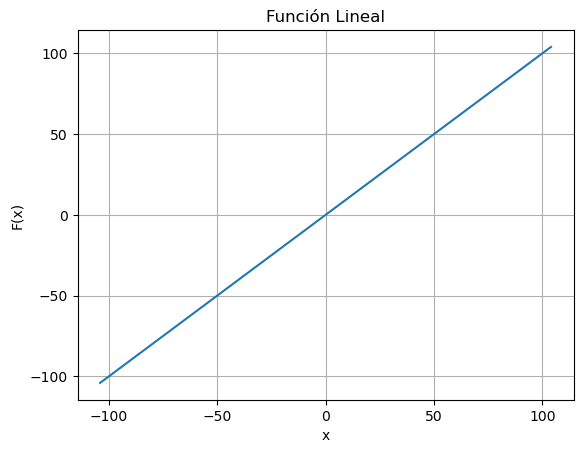

In [42]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-104, 105, 16)

# ecuación de la función lineal: F(x) = x
y = x

plt.title("Función Lineal")
plt.xlabel("x")
plt.ylabel("F(x)")

plt.plot(x, y)

plt.grid()
plt.show()

Como repetiremos siempre los mismos pasos (título, etiquetas, plot, grid, show), conviene encapsularlos en una **función reutilizable**. Graficamos la parábola $f(x) = 4x^2$:

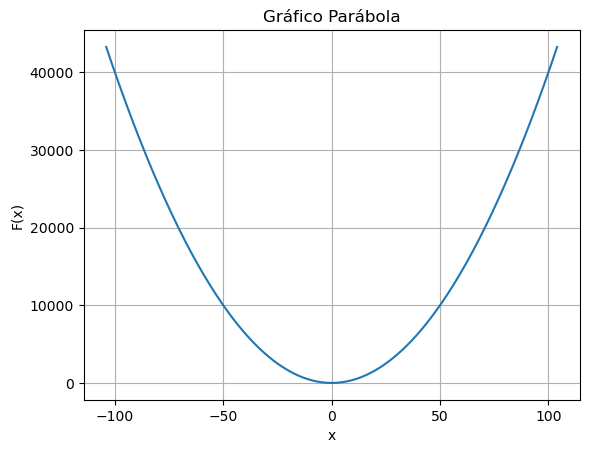

In [43]:
def graficar(x, y, title):

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("F(x)")
    plt.plot(x, y)
    plt.grid()
    plt.show()

x = np.arange(-104, 105, 1)
y = 4 * x**2

graficar(x, y, "Gráfico Parábola")

Ecuación cuadrática $f(x) = x^2 + 3x + 5$:

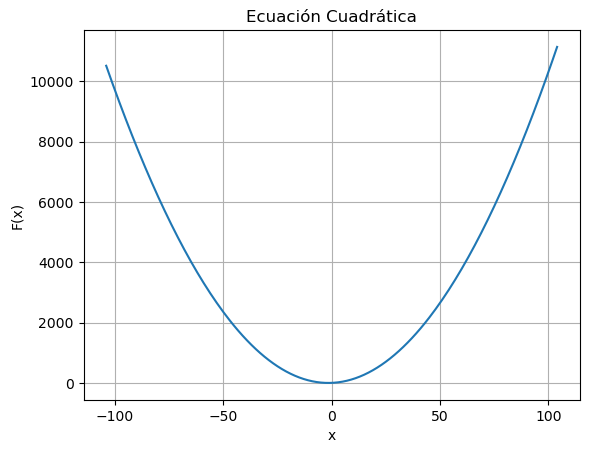

In [44]:
x = np.arange(-104, 105, 1)
y = x**2 + 3*x + 5

graficar(x, y, "Ecuación Cuadrática")

### 📝 Ejercicio 1 — Función seno

Realice un gráfico de línea de la función trigonométrica seno

$$f(x) = \sin(x)$$

cuyo dominio va de $0$ a $2\pi$. Use la función `graficar` definida en clase (o cree una propia que además reciba las etiquetas de los ejes).

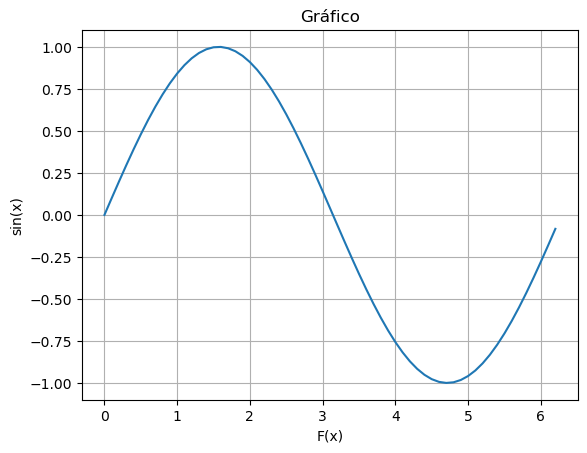

In [45]:
# Escriba su solución aquí
import math as mt
import numpy as np
import matplotlib.pyplot as plt

def graficar(x, y, title, et_x, et_y):
    plt.title(title)
    plt.xlabel(et_x)
    plt.ylabel(et_y)
    plt.plot(x, y)
    plt.grid()
    plt.show()

# valores de la X 
x = np.arange(0, 2 * np.pi, 0.1)
# print("x",x)
# valores de la Y (el seno de cada x)
y = np.sin(x)

#print("y",y)

graficar(x, y, "Gráfico","F(x)","sin(x)")

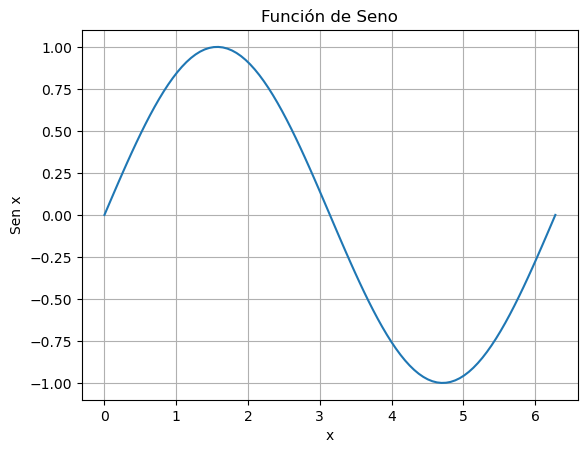

In [46]:
import numpy as np
import matplotlib.pyplot as plt


def graficar(x, y, tittle):
    plt.plot(x, y)
    plt.xlabel("x")
    plt.ylabel("Sen x")
    plt.title("Función de Seno")
    plt.grid()
    plt.show()


x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)


graficar(x, y,"Función seno")

### 📝 Ejercicio 2 — Gráfico de temperaturas desde un CSV

Realice el gráfico de línea de la temperatura de Lima del viernes 21 de noviembre de 2025 (hora vs temperatura), a partir del archivo `dataset/temperatura/lima_21112025.csv`.

Fuente: https://www.tiempo3.com/south-america/peru/lima?page=past-weather#day=21&month=11

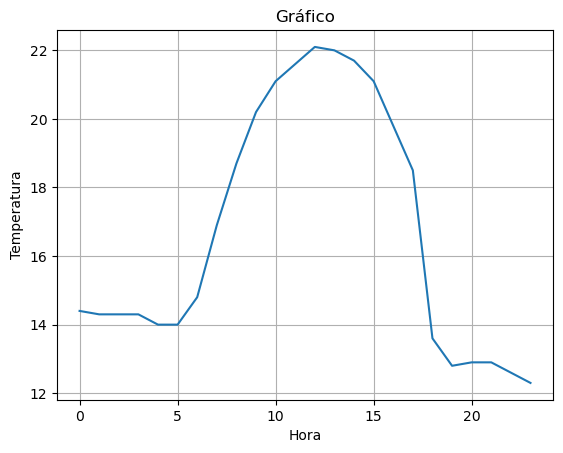

In [47]:
# Escriba su solución aquí
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


def graficar(x, y, title, et_x, et_y):
    plt.title(title)
    plt.xlabel(et_x)
    plt.ylabel(et_y)
    plt.plot(x, y)
    plt.grid()
    plt.show()
    
datax = pd.read_csv("dataset/temperatura/lima_21112025.csv", header=None, usecols=[0])
datay = pd.read_csv("dataset/temperatura/lima_21112025.csv", header=None, usecols=[1])

#print("x",datax)
#print("y",datay)

graficar(datax, datay, "Gráfico","Hora", "Temperatura")

Fuente datos : https://open-meteo.com/en/docs/historical-weather-api?latitude=-12.0432&longitude=-77.0282&start_date=2026-07-13#location_and_time

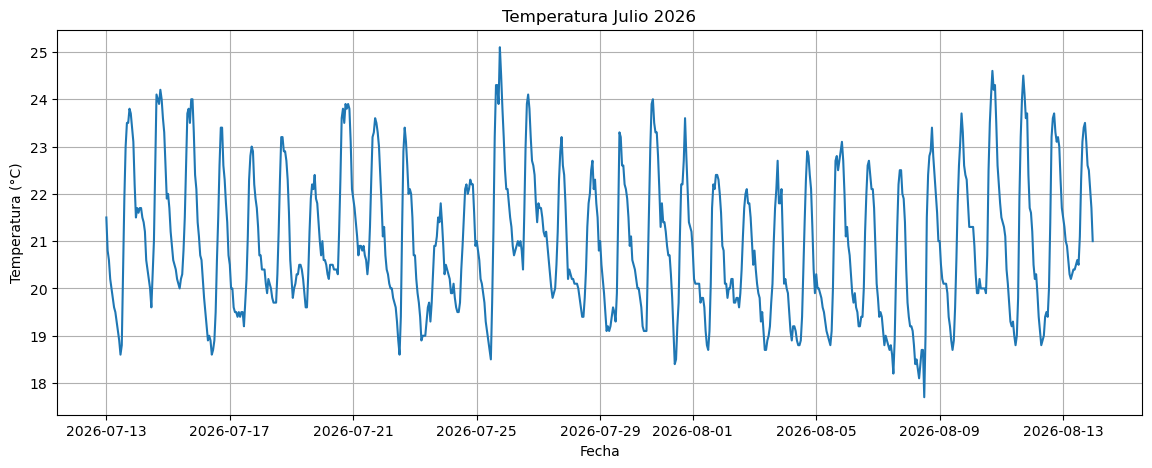

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("dataset/temperatura/open-meteo-Lima_072026.csv",sep=",")

data["time"] = data["time"]

# Convertir la columna "time" a tipo datetime
data["time"] = pd.to_datetime(data["time"])

def graficar(x, y, tittle):
    plt.figure(figsize=(14, 5))
    plt.plot(x, y)
    plt.xlabel("Fecha")
    plt.ylabel("Temperatura (°C)")
    plt.title(tittle)
    plt.grid()
    plt.show()


graficar(
    data["time"],
    data["temperature"],
    "Temperatura Julio 2026")

In [49]:
data.head()

,time,temperature
0,2026-07-13 00:00:00,21.5
1,2026-07-13 01:00:00,20.8
2,2026-07-13 02:00:00,20.6
3,2026-07-13 03:00:00,20.2
4,2026-07-13 04:00:00,20.0


Fuente de datos : https://www.tiempo3.com/south-america/peru/loreto/lima?page=past-weather#day=13&month=8

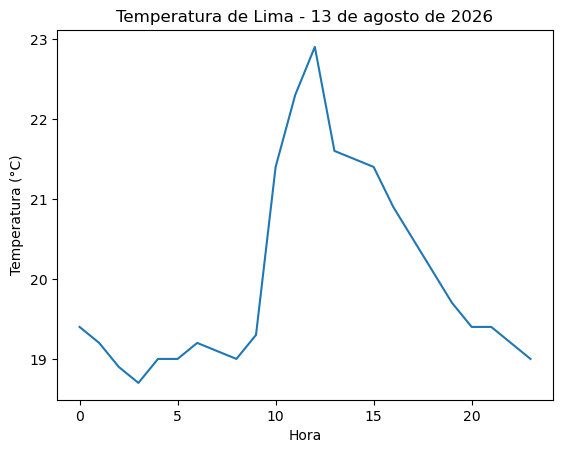

In [50]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(
    "dataset/temperatura/lima_13082026.csv",
    sep=",",
    header=None
)


plt.plot(df[0], df[1])


plt.xlabel("Hora")
plt.ylabel("Temperatura (°C)")
plt.title("Temperatura de Lima - 13 de agosto de 2026")


plt.show()

### 📝 Ejercicio 2.2 — Gráfico de temperaturas desde un CSV ( Junio 2026)

Realice el gráfico de línea de la temperatura de Lima de mes de Junio 2026

Fuente: https://open-meteo.com/en/docs/historical-weather-ap

In [51]:
# Escriba su solución aquí


## Funciones personalizadas


In [52]:
def graficar(x, y, title):

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("F(x)")
    plt.plot(x, y)
    plt.grid()
    plt.show()


Podemos graficar cualquier modelo matemático definido como función de Python. Por ejemplo:

$$f(x) = \frac{1}{1 + x^2}$$

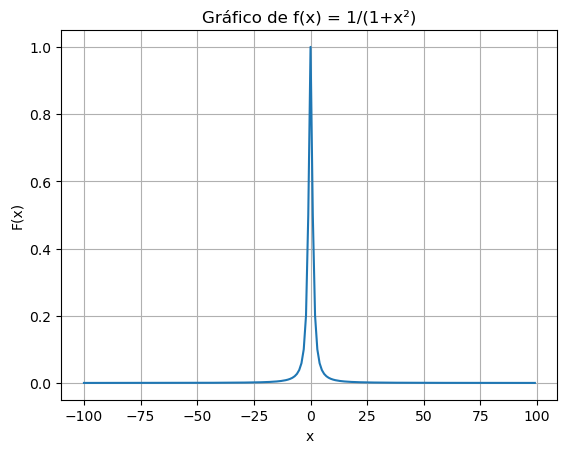

In [53]:
def func(x):
    modelo = 1 / (1 + x**2)
    return modelo

x = np.arange(-100, 100, 1)
y = func(x)

graficar(x, y, "Gráfico de f(x) = 1/(1+x²)")

**Función Softmax**

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \qquad \text{para } i = 1, \dots, K$$

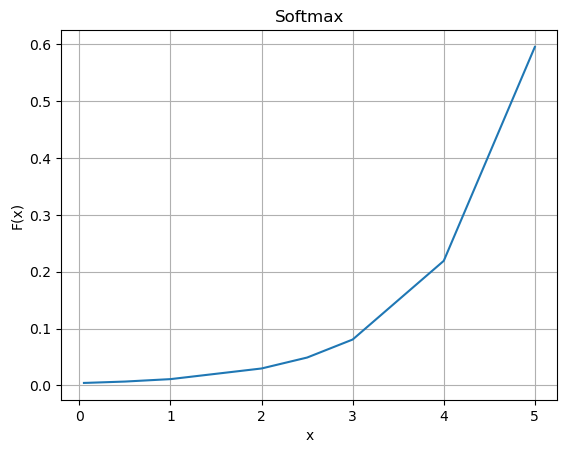

In [54]:

def softmax(x):

    exp_x = np.exp(x - np.max(x))

    sm = exp_x / np.sum(exp_x)

    return sm

x = np.array([5, 4, 3,2.5, 2, 1, 0.5,  0.1, 0.05])

y = softmax(x)

graficar(x, y, "Softmax")

## Personalización de gráficos

### Teoría

`plt.plot` acepta parámetros para controlar la apariencia de cada línea:

| Parámetro | Ejemplos | Descripción |
|---|---|---|
| `color` | `"blue"`, `"red"`, `"#2ca02c"` | Color de la línea |
| `linestyle` | `"-"`, `"--"`, `":"`, `"-."` | Continua, discontinua, punteada |
| `marker` | `"o"`, `"s"`, `"^"` | Marcador en cada punto |
| `label` | `"sin(x)"` | Texto para la leyenda |

Otras funciones útiles: `plt.xlim(a, b)` y `plt.ylim(a, b)` acotan los ejes; `plt.text(x, y, "texto")` agrega anotaciones en coordenadas del gráfico; `plt.savefig(ruta)` guarda la figura.

### Laboratorio: varias líneas en un mismo gráfico

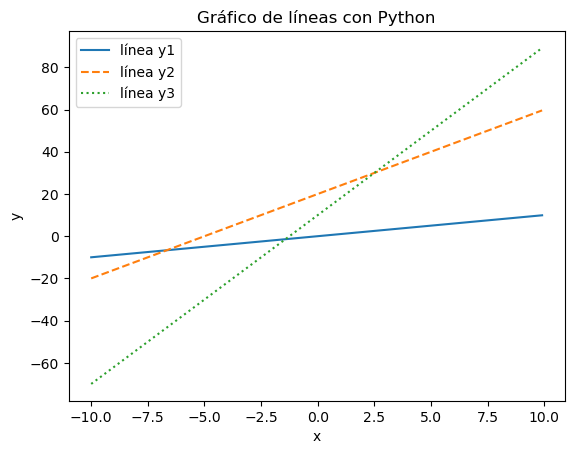

In [55]:
#import os
#os.makedirs("output", exist_ok=True)   # crea la carpeta si no existe

x = np.arange(-10, 10, 0.1)

y1 = x
y2 = 4*x + 20
y3 = 8*x + 10

plt.title("Gráfico de líneas con Python")

plt.plot(x, y1, label="línea y1")
plt.plot(x, y2, label="línea y2", linestyle="--")
plt.plot(x, y3, label="línea y3", linestyle=":")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")

plt.savefig("output/fig-01")
plt.show()

Combinando funciones en un modelo propio:

$$g(x) = \log_{10}(x) \cdot \left(3x^3 + 5x^2 + 4x + 4\right)$$

$$g(x) = h(x) * n(x)$$


> ⚠️ Ojo con el **dominio**: $\log_{10}(x)$ no está definido para $x \leq 0$, por eso el rango empieza en un valor mayor que cero. Si empezara en 0, numpy devolvería `-inf` y un *warning*.

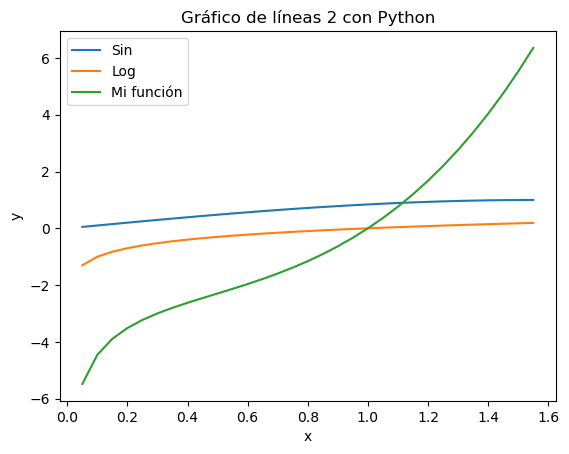

In [56]:
def mi_modelo(x):
    h = np.log10(x)
    n = 3 * pow(x, 3) + 5 * pow(x, 2) + 4 * x + 4
    return h*n

# El rango empieza en 0.05 (no en 0) para evitar log10(0)
x = np.arange(0.05, np.pi / 2, 0.05)

y1 = np.sin(x)
y2 = np.log10(x)
y3 = mi_modelo(x)

plt.title("Gráfico de líneas 2 con Python")
plt.plot(x, y1, label="Sin")
plt.plot(x, y2, label="Log")
plt.plot(x, y3, label="Mi función")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

plt.savefig("output/fig-02")
plt.show()

### 📝 Ejercicio 3 — Personalización: seno y coseno en un mismo gráfico

Grafique $\sin(x)$ y $\cos(x)$ **en un mismo sistema de ejes**, con dominio $[0, 2\pi]$, cumpliendo:

1. Cada curva con un color y estilo de línea distintos (por ejemplo, una continua y otra punteada).
2. Leyenda que identifique cada función.
3. Título y etiquetas en ambos ejes.
4. Guardar la figura como `output/ejercicio_03.png`.

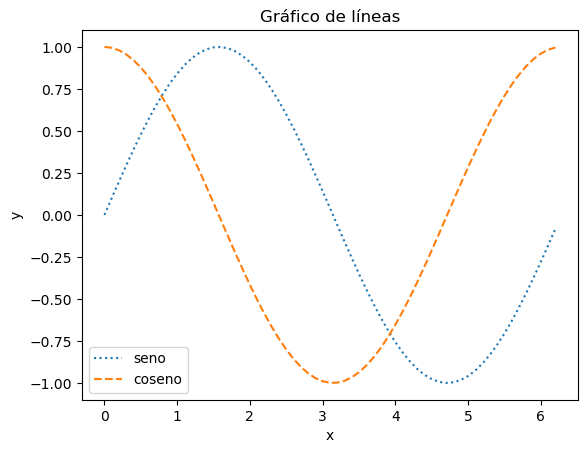

In [57]:
# Escriba su solución aquí
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# valores de la X 
x = np.arange(0, 2 * np.pi, 0.1)

# valores de la Y (el seno y coseno de cada x)
ysen = np.sin(x)
ycos = np.cos(x)


plt.title("Gráfico de líneas")

plt.plot(x, ysen, label="seno", linestyle=":")
plt.plot(x, ycos, label="coseno", linestyle="--")
#plt.plot(x, y3, label="línea y3", linestyle=":")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")

plt.savefig("output/ejercicio_03.png")
plt.show()

## Subgráficos

### Teoría

`plt.subplot(filas, columnas, posición)` divide la figura en una grilla y activa una celda. La posición se numera de izquierda a derecha y de arriba hacia abajo, empezando en 1.

### Laboratorio: las cuatro funciones trigonométricas

> ⚠️ La tangente y la cotangente tienen **asíntotas** (tienden a $\pm\infty$). Si no acotamos el eje $y$ con `ylim`, matplotlib ajusta la escala a los valores gigantes y la forma de la curva se pierde. Además, la cotangente no está definida en $x = 0$, por eso el rango empieza en 0.05.

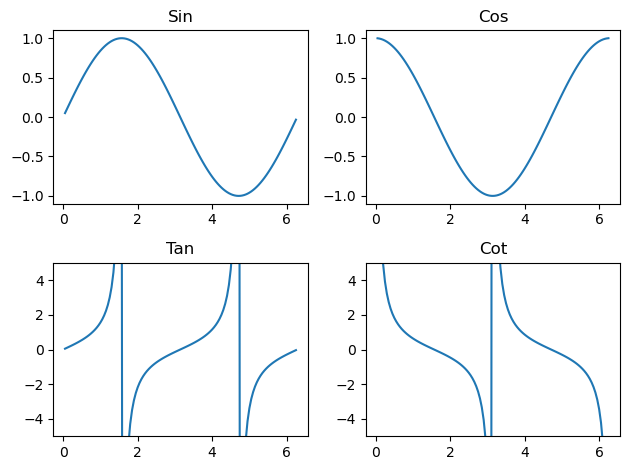

In [58]:
x = np.arange(0.05, 2 * np.pi, 0.05)

y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.tan(x)
y4 = 1 / np.tan(x)

plt.subplot(2, 2, 1)
plt.title("Sin")
plt.plot(x, y1)

plt.subplot(2, 2, 2)
plt.title("Cos")
plt.plot(x, y2)

plt.subplot(2, 2, 3)
plt.title("Tan")
plt.plot(x, y3)
plt.ylim(-5, 5)      # acotamos por las asíntotas

plt.subplot(2, 2, 4)
plt.title("Cot")
plt.plot(x, y4)
plt.ylim(-5, 5)

plt.tight_layout()
plt.show()

### 📝 Ejercicio 4 — Subgráficos: seno y coseno

Realice un gráfico de línea de las funciones seno y coseno **en dos gráficos distintos** (lado a lado), cuyo dominio va de $0$ a $2\pi$, utilizando el método `subplot`. Agregue título y cuadrícula a cada subgráfico.

In [59]:
# Escriba su solución aquí


## Gráficos de líneas a partir de DataFrames

### Teoría

Las Series y DataFrames de pandas tienen el método `.plot()`, que usa matplotlib por debajo. El parámetro `kind` selecciona el tipo de gráfico: `"line"` (por defecto), `"area"`, `"bar"`, `"barh"`, `"hist"`, `"box"`, entre otros. Después de llamar a `.plot()` podemos seguir usando las funciones de `plt` (título, etiquetas, grid) antes de `plt.show()`.

### Laboratorio

Trabajaremos con la información del FMI: https://www.imf.org/en/publications/sprolls/world-economic-outlook-databases

> Los archivos del FMI de distintos años usan encabezados distintos (`Country` en el 2022, `COUNTRY` en el 2025 y 2026). Por eso renombramos la columna al cargar.

In [60]:
import pandas as pd

FILE_NAME = "dataset/fmi/WEO_Data_Latinoamerica_2026.csv"

df = pd.read_csv(FILE_NAME, sep=",")

df.rename(columns={"COUNTRY": "País"}, inplace=True)

df.set_index("País", inplace=True)

df.head()

,DATASET,SERIES_CODE,OBS_MEASURE,INDICATOR,FREQUENCY,SCALE,2000,2001,2002,2003,...,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031
País,,,,,,,,,,,,,,,,,,,,,
Argentina,IMF.RES:WEO(9.0.0),ARG.NGDPD.A,OBS_VALUE,"Gross domestic product (GDP), Current prices, ...",Annual,Billions,317.759,300.421,112.458,142.431,...,633.520,648.895,637.234,681.485,688.378,703.668,746.843,789.967,833.284,878.051
Bolivia,IMF.RES:WEO(9.0.0),BOL.NGDPD.A,OBS_VALUE,"Gross domestic product (GDP), Current prices, ...",Annual,Billions,9.371,9.100,8.895,9.056,...,51.331,52.722,55.281,64.250,80.743,NaN,NaN,NaN,NaN,NaN
Colombia,IMF.RES:WEO(9.0.0),COL.NGDPD.A,OBS_VALUE,"Gross domestic product (GDP), Current prices, ...",Annual,Billions,99.270,97.606,97.353,94.072,...,345.632,366.901,420.504,457.410,539.530,554.384,578.238,604.409,632.137,661.138
Brazil,IMF.RES:WEO(9.0.0),BRA.NGDPD.A,OBS_VALUE,"Gross domestic product (GDP), Current prices, ...",Annual,Billions,655.454,559.982,509.798,558.232,...,1951.849,2191.137,2185.822,2279.918,2635.912,2766.558,2879.420,3037.171,3203.508,3378.877
Ecuador,IMF.RES:WEO(9.0.0),ECU.NGDPD.A,OBS_VALUE,"Gross domestic product (GDP), Current prices, ...",Annual,Billions,17.531,23.127,27.054,30.965,...,116.133,120.793,123.802,130.321,138.194,144.135,150.136,156.661,163.818,171.302


In [61]:
# Lista de años como strings (los encabezados del CSV son texto)
anhos = list(map(str, range(2000, 2028)))

anhos

['2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025',
 '2026',
 '2027']

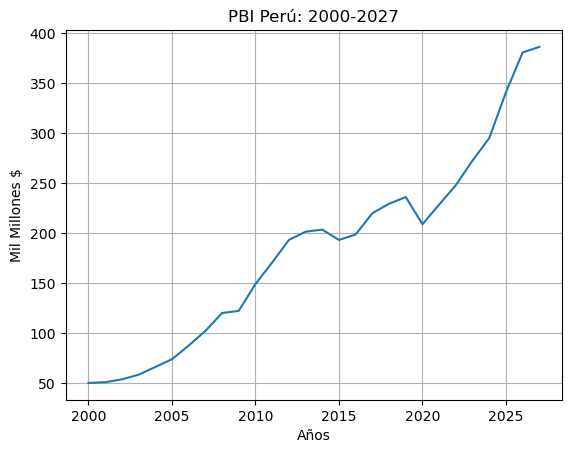

In [62]:
info_peru = df.loc["Peru", anhos]
info_peru.plot()
plt.title("PBI Perú: 2000-2027")
plt.xlabel("Años")
plt.ylabel("Mil Millones $")
plt.grid()
plt.show()

Con `plt.text(x, y, "texto")` podemos anotar eventos sobre el gráfico (la coordenada x es la **posición** del año en el eje, no el año en sí):

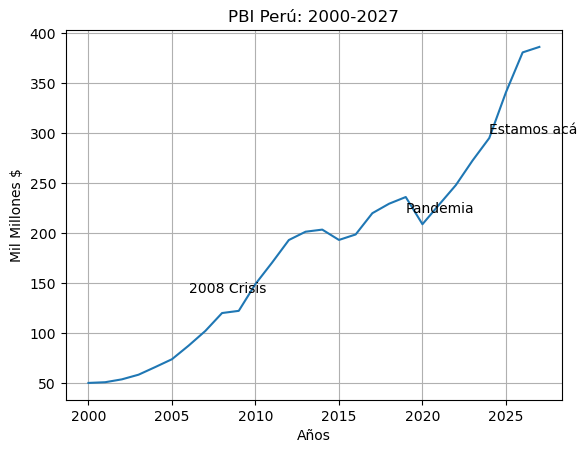

In [63]:
info_peru = df.loc["Peru", anhos]
info_peru.plot(kind="line")
plt.title("PBI Perú: 2000-2027")
plt.xlabel("Años")
plt.ylabel("Mil Millones $")
plt.text(6, 140, "2008 Crisis")
plt.text(19, 220, "Pandemia")
plt.text(24, 300, "Estamos acá")
plt.grid()
plt.savefig("output/fig-03")
plt.show()

Para graficar **varios países** seleccionamos varias filas y **transponemos**: así los años quedan como índice (eje x) y cada país como una columna (una línea):

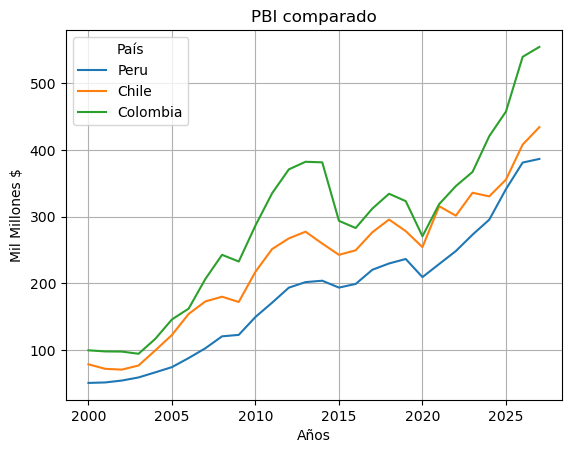

In [64]:
 
paises = df.loc[["Peru", "Chile", "Colombia"], anhos]

paises = paises.T   # Transpuesta: años como filas

paises.plot()

plt.title("PBI comparado")
plt.xlabel("Años")
plt.ylabel("Mil Millones $")
plt.grid()
plt.show()

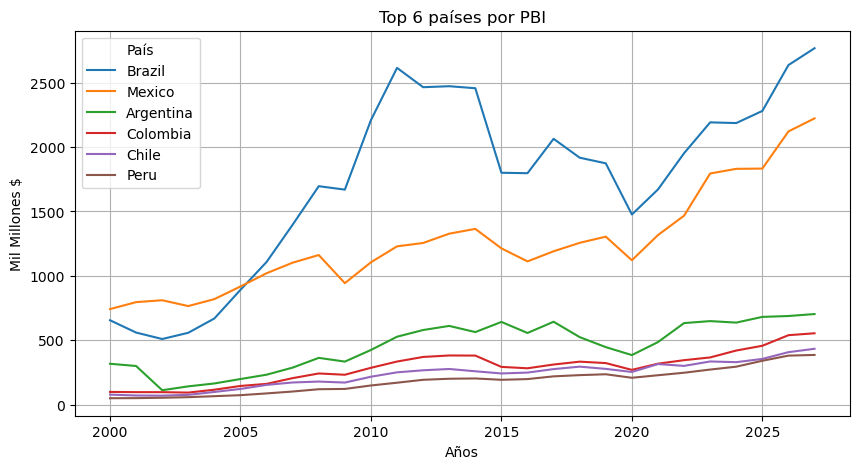

In [65]:
# Top 6 países por PBI 2026
df.sort_values(by="2026", ascending=False, inplace=True)
df_top5 = df[anhos].head(6).T
df_top5.plot(figsize=(10, 5))
plt.title("Top 6 países por PBI")
plt.xlabel("Años")
plt.ylabel("Mil Millones $")
plt.grid()
plt.show()

### 📝 Ejercicio 5 — Países con menor PBI

Grafique el PBI (2001–2026) de los **3 países con menor PBI en el año 2023**.

> Nota: a partir del año 2024 no hay información del PBI de Venezuela.

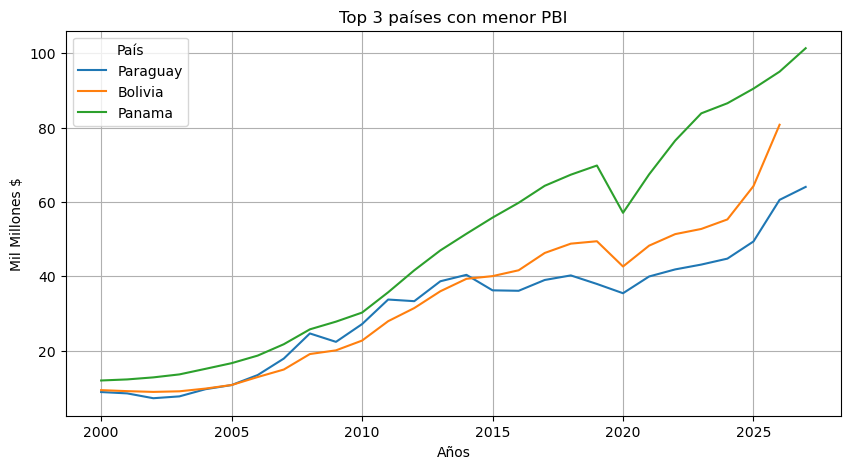

In [66]:
# Escriba su solución aquí
df.sort_values(by="2026", ascending=True, inplace=True)


df_top3 = df[anhos].head(3).T


df_top3.plot(figsize=(10, 5))
plt.title("Top 3 países con menor PBI")
plt.xlabel("Años")
plt.ylabel("Mil Millones $")
plt.grid()

## Gráficos de áreas

Un gráfico de área es un gráfico de línea con la región bajo la curva rellena. Con `stacked=False` las áreas se superponen (cada país desde cero) y `alpha` controla la transparencia — sin ella, las áreas se taparían entre sí:

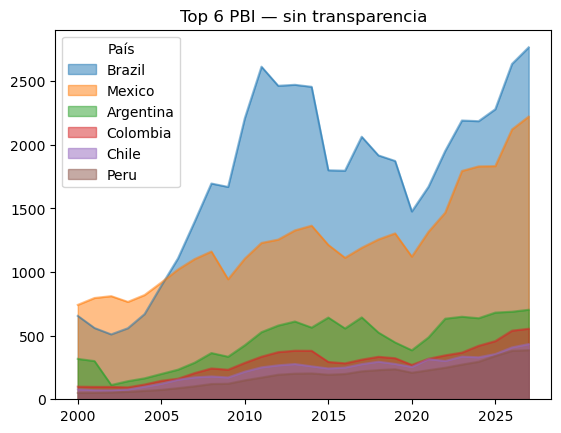

In [67]:
df.sort_values(by="2026", ascending=False, inplace=True)
df_top6 = df[anhos].head(6).T
df_top6.plot(kind="area", stacked=False)
plt.title("Top 6 PBI — sin transparencia")
plt.show()

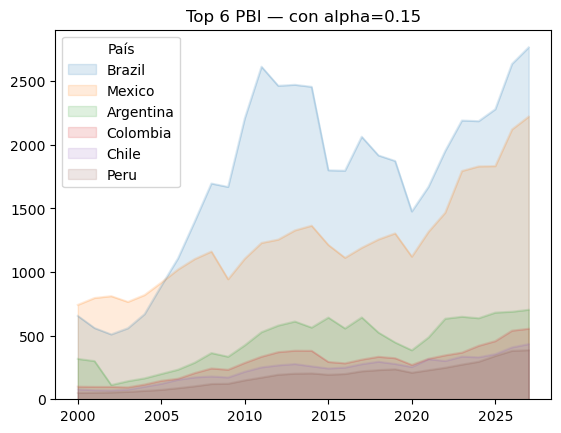

In [68]:
df_top6.plot(kind="area", alpha=0.15, stacked=False)
plt.title("Top 6 PBI — con alpha=0.15")
plt.show()

### 📝 Ejercicio 6 — Gráfico de áreas del PBI

A partir del archivo `WEO_Data_Latinoamerica_2026.csv`, realice un gráfico de áreas del PBI del año 2001 al 2006 de los siguientes países: Brasil, México, Argentina, Colombia, Chile y Perú.

> Este archivo usa la columna `Country` (no `COUNTRY`).

In [69]:
# Escriba su solución aquí


## Gráficos de barras

### Teoría

Las barras comparan **categorías** (países, productos, meses). Variantes:
- `kind="bar"`: barras verticales.
- `kind="barh"`: barras horizontales — preferibles cuando las etiquetas de categoría son largas.
- `plt.annotate(texto, xy=(x, y))` permite escribir el valor junto a cada barra.

### Laboratorio

In [70]:
nombre_archivo = "dataset/fmi/WEO_Data_Latinoamerica_2026.csv"

df = pd.read_csv(nombre_archivo, thousands=",", decimal=".", sep=",")

df.head(2)

,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,FREQUENCY,SCALE,2000,2001,2002,...,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031
0,IMF.RES:WEO(9.0.0),ARG.NGDPD.A,OBS_VALUE,Argentina,"Gross domestic product (GDP), Current prices, ...",Annual,Billions,317.759,300.421,112.458,...,633.520,648.895,637.234,681.485,688.378,703.668,746.843,789.967,833.284,878.051
1,IMF.RES:WEO(9.0.0),BOL.NGDPD.A,OBS_VALUE,Bolivia,"Gross domestic product (GDP), Current prices, ...",Annual,Billions,9.371,9.100,8.895,...,51.331,52.722,55.281,64.250,80.743,NaN,NaN,NaN,NaN,NaN


In [71]:
# Se configura el indice del DataFrame para que la columna "COUNTRY" sea el índice,
# lo que permite acceder a los datos por país de manera más sencilla. Esto es útil para realizar análisis y visualizaciones 
# específicas de cada país.
df.set_index("COUNTRY", inplace=True)

df.head(2)

,DATASET,SERIES_CODE,OBS_MEASURE,INDICATOR,FREQUENCY,SCALE,2000,2001,2002,2003,...,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031
COUNTRY,,,,,,,,,,,,,,,,,,,,,
Argentina,IMF.RES:WEO(9.0.0),ARG.NGDPD.A,OBS_VALUE,"Gross domestic product (GDP), Current prices, ...",Annual,Billions,317.759,300.421,112.458,142.431,...,633.520,648.895,637.234,681.485,688.378,703.668,746.843,789.967,833.284,878.051
Bolivia,IMF.RES:WEO(9.0.0),BOL.NGDPD.A,OBS_VALUE,"Gross domestic product (GDP), Current prices, ...",Annual,Billions,9.371,9.100,8.895,9.056,...,51.331,52.722,55.281,64.250,80.743,NaN,NaN,NaN,NaN,NaN


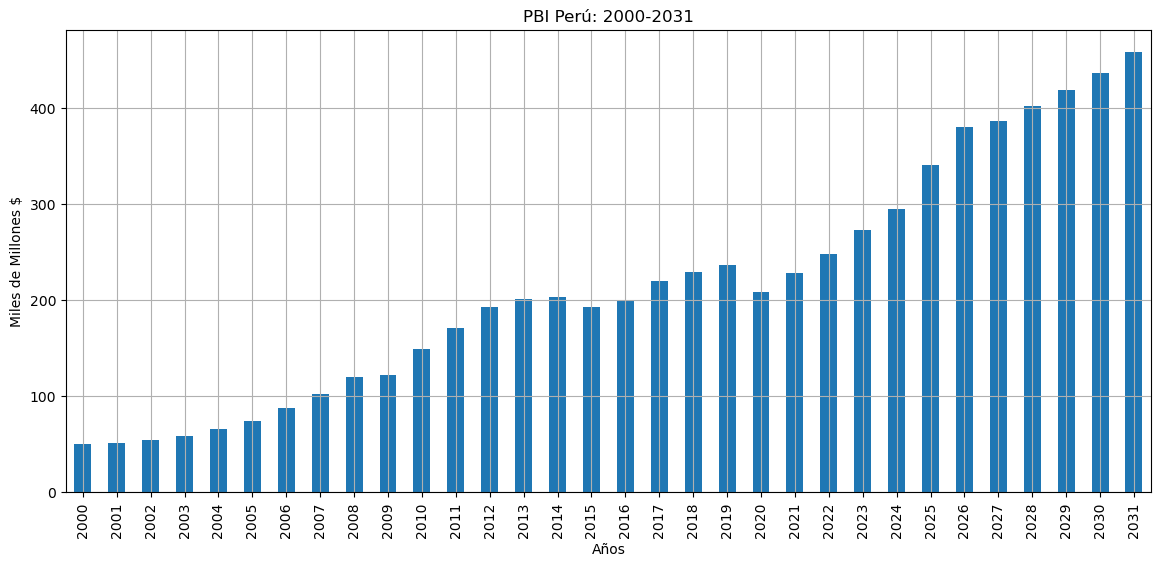

In [72]:
anhos = list(map(str, range(2000, 2032)))

info_peru = df.loc["Peru", anhos]

# Defino el tamaño de la figura
plt.figure(figsize=(14, 6))

# Dibujo sobre la figura anterior
info_peru.plot(kind="bar")

# Personalizo
plt.title("PBI Perú: 2000-2031")
plt.xlabel("Años")
plt.ylabel("Miles de Millones $")
plt.grid()
plt.show()

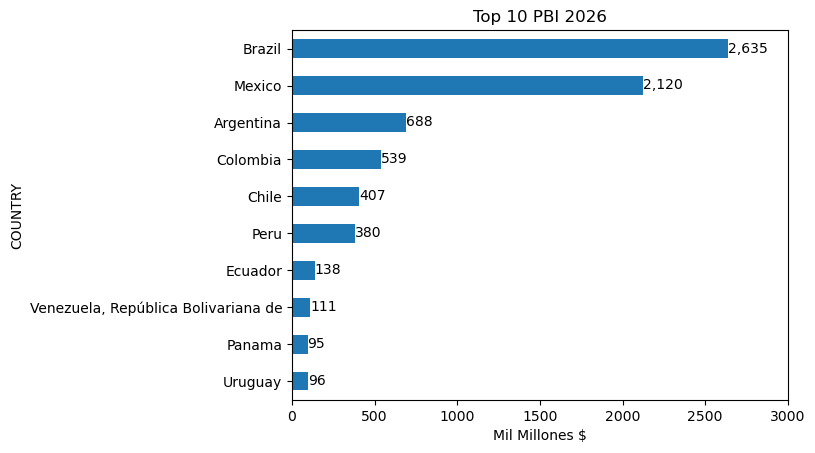

In [73]:
# Barras horizontales con anotaciones: top 10 por PBI 2026
df.sort_values(by="2025", ascending=True, inplace=True)
df_top = df["2026"].tail(10)
df_top.plot(kind="barh")
plt.xlim(0, 3000)
plt.title("Top 10 PBI 2026")
plt.xlabel("Mil Millones $")


#''' Colocar el valor del PBI al final de la grafica de cada país.
for index, value in enumerate(df_top):
    if not np.isnan(value):
        label = format(int(value), ",")
        plt.annotate(label, xy=(value, index - 0.1))
#'''
plt.show()

### 📝 Ejercicio 7 — Gráfico de barras del medallero

A partir del archivo `medallero_Panamericanos_Santiago2023.csv`, realice un gráfico de **barras horizontales** con los 10 países que más medallas de **Oro** obtuvieron, mostrando el valor de cada barra como anotación.

In [ ]:
# Escriba su solución aquí



## Histogramas

### Teoría

Un **histograma** muestra la **distribución** de una variable numérica: divide el rango de valores en $k$ intervalos consecutivos (*bins*) de ancho

$$w = \frac{x_{max} - x_{min}}{k}$$

y grafica cuántas observaciones (**frecuencia**) caen en cada intervalo. A diferencia del gráfico de barras (categorías separadas), en el histograma el eje x es **continuo**.

La elección de `bins` afecta la lectura: pocos bins ocultan detalles, demasiados generan ruido.

`np.histogram(datos, bins=k)` devuelve las frecuencias y los bordes de los intervalos; `.plot(kind="hist")` los grafica directamente.

### Laboratorio

In [37]:
df["2025"]

COUNTRY
Paraguay                                 49.358
Bolivia                                  64.250
Uruguay                                  85.575
Panama                                   90.463
Venezuela, República Bolivariana de      99.661
Ecuador                                 130.321
Peru                                    341.025
Chile                                   355.346
Colombia                                457.410
Argentina                               681.485
Mexico                                 1832.641
Brazil                                 2279.918
Name: 2025, dtype: float64

In [33]:
# Frecuencias y bordes de los bins (10 por defecto)
np.histogram(df["2025"])

(array([6, 3, 1, 0, 0, 0, 0, 1, 0, 1]),
 array([  49.358,  272.414,  495.47 ,  718.526,  941.582, 1164.638,
        1387.694, 1610.75 , 1833.806, 2056.862, 2279.918]))

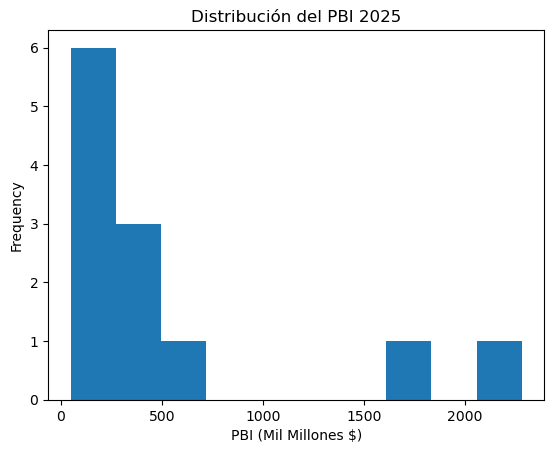

In [34]:
df["2025"].plot(kind="hist", bins=10)
plt.title("Distribución del PBI 2025")
plt.xlabel("PBI (Mil Millones $)")
plt.show()

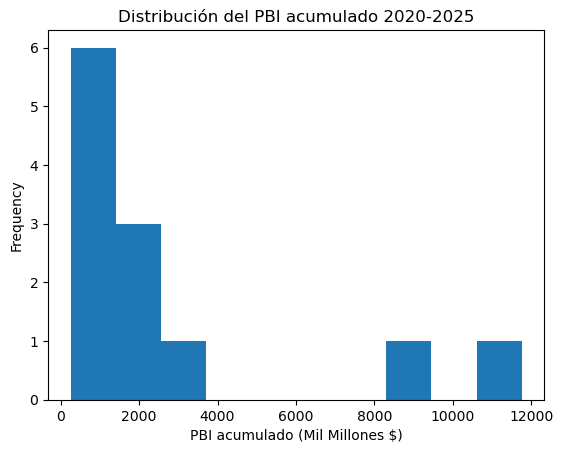

In [38]:
# Histograma del PBI acumulado 2020-2025
df["2020-2025"] = df["2020"] + df["2021"] + df["2022"] + df["2023"] + df["2024"] + df["2025"]

df["2020-2025"].plot.hist(bins=10)
plt.title("Distribución del PBI acumulado 2020-2025")
plt.xlabel("PBI acumulado (Mil Millones $)")
plt.show()

### 📝 Ejercicio 8 — Histograma del PBI

A partir del archivo `WEO_Data_Latinoamerica_2025.csv`, grafique un **histograma** del número de países cuyo PBI sea mayor a los 250 000 millones de dólares en el año 2025.

> Recuerde que los valores del archivo están en **miles de millones**, por lo que 250 000 millones equivale a un valor de $250$ en la columna.

Text(0, 0.5, 'Número de países')

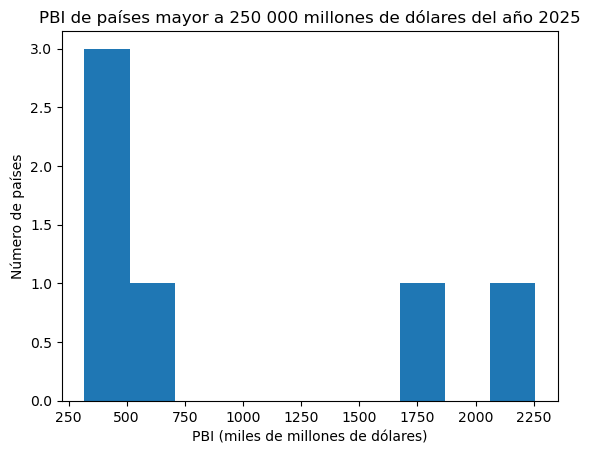

In [74]:
# Escriba su solución aquí
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("dataset/fmi//WEO_Data_Latinoamerica_2025.csv")


paises = df[df["2025"] > 250]


plt.hist(paises["2025"])


plt.title("PBI de países mayor a 250 000 millones de dólares del año 2025")
plt.xlabel("PBI (miles de millones de dólares)")
plt.ylabel("Número de países")




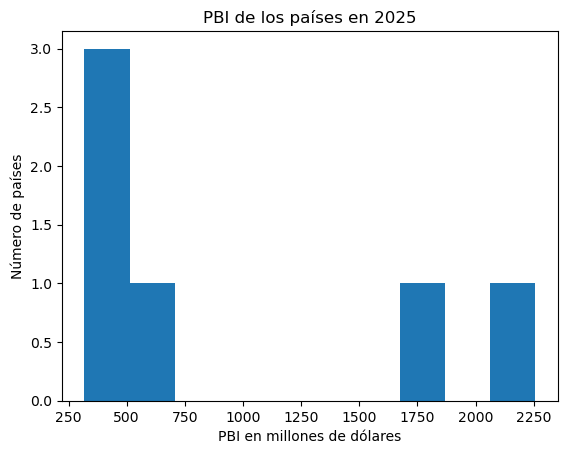

In [75]:
pbi = df[df["2025"] > 250]["2025"]

pbi.plot.hist(bins=10)

plt.title("PBI de los países en 2025")
plt.xlabel("PBI en millones de dólares")
plt.ylabel("Número de países")
plt.show()

## Gráfico de cajas: Boxplot

### Teoría

El **boxplot** resume la distribución de una variable con los cuartiles que vimos en la sesión 02:

- La **caja** va de $Q_1$ a $Q_3$ (contiene el 50% central de los datos, es decir, el $IQR$).
- La línea dentro de la caja es la **mediana** ($Q_2$).
- Los **bigotes** se extienden hasta el último dato dentro de los límites

$$[\,Q_1 - 1.5 \cdot IQR,\;\; Q_3 + 1.5 \cdot IQR\,]$$

- Los puntos fuera de los bigotes son **valores atípicos** (*outliers*) — el mismo criterio del ejercicio de outliers de la sesión anterior.

Es ideal para **comparar distribuciones** entre grupos lado a lado.


<img src="imagenes/boxplot.png" width="400" />





### Laboratorio

In [39]:
df = pd.read_csv("dataset/panamericanos/medallero_Panamericanos_Lima2019.csv")
df.head(10)

,Posicion,Pais,Oro,Plata,Bronce,Total,RankingTotal,Zona
0,1,Estados Unidos,120,88,85,293,1,America del Norte
1,2,Brasil,55,45,71,171,2,America del Sur
2,3,México,37,36,63,136,4,America del Norte
3,4,Canadá,35,64,53,152,3,America del Norte
4,5,Cuba,33,27,38,98,6,America del Centro
5,6,Argentina,32,35,34,101,5,America del Sur
6,7,Colombia,28,23,33,84,7,America del Sur
7,8,Chile,13,19,18,50,8,America del Sur
8,9,Perú,11,7,21,39,11,America del Sur
9,10,República Dominicana,10,13,17,40,10,America del Centro


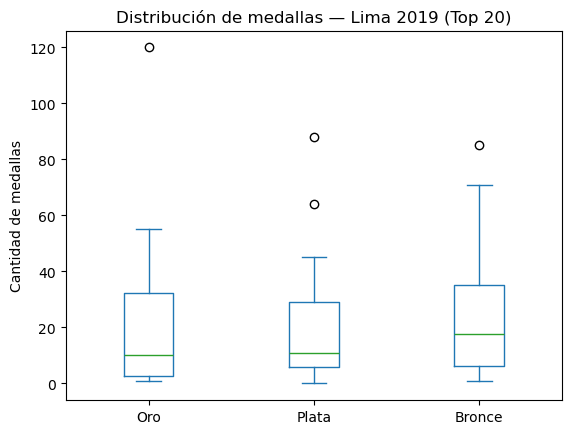

In [40]:
# Selecciono los 20 primeros
df_top_20 = df.head(20) 

df_top_20[["Oro", "Plata", "Bronce"]].plot.box()
plt.title("Distribución de medallas — Lima 2019 (Top 20)")
plt.ylabel("Cantidad de medallas")
plt.show()

# Los círculos por encima de los bigotes son outliers:
# países cuya cantidad de medallas se aleja mucho del resto (p. ej. EEUU).

### 📝 Ejercicio 09 — Boxplot comparativo de medalleros

Compare la distribución de medallas de **Oro, Plata y Bronce** (top 20 países) de los Panamericanos de **Santiago 2023**

Responda: ¿en cuál edición se observan valores atípicos más extremos en la medalla de Oro?

In [40]:
# Escriba su solución aquí


### 📝 Ejercicio 10 — Boxplot comparativo de medalleros

Compare la distribución de medallas de **Oro, Plata y Bronce** (top 20 países) entre los Panamericanos de **Lima 2019** y **Santiago 2023**, usando dos boxplots lado a lado con `subplot`.

Responda: ¿en cuál edición se observan valores atípicos más extremos en la medalla de Oro?

In [ ]:
# Escriba su solución aquí
